# Stage 2: Expected Revenue + Combined CLV

Estimates **expected revenue per buyer** using spend-tier averages, then combines with Stage 1 purchase probability.

**Why not individual regression?** An XGBoost regressor trained on the 6,451 holdout buyers produced R² = -0.03 (worse than predicting the mean). Individual revenue is too noisy to predict — the features predict *who* buys, not *how much*. Instead, we use historical spend tiers as a natural revenue proxy.

- **Approach:** Bin customers by `monetary_value` into spend tiers, compute tier-level average holdout revenue
- **Combined CLV:** `clv_180d = p_purchase × tier_avg_revenue`

**Outputs:**
- `data/processed/clv_scored.csv`

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import warnings
warnings.filterwarnings('ignore')

## 1. Load Stage 1 Output

In [2]:
df = pd.read_csv('../data/processed/stage1_scored.csv')
print(f"Loaded {len(df):,} customers")
print(f"p_purchase range: [{df['p_purchase'].min():.4f}, {df['p_purchase'].max():.4f}]")

# Holdout buyers
buyers = df[df['actual_holdout_transactions'] > 0].copy()
print(f"Holdout buyers: {len(buyers):,} ({len(buyers)/len(df):.1%})")

Loaded 52,507 customers
p_purchase range: [0.0000, 0.6987]
Holdout buyers: 6,451 (12.3%)


## 2. Spend Tier Construction

Bin all customers by `monetary_value` (historical avg order value) into terciles. Then compute the actual average holdout revenue per buyer within each tier.

In [3]:
# Create spend tiers using terciles of monetary_value (all customers)
df['spend_tier'] = pd.qcut(
    df['monetary_value'], q=3,
    labels=['Low Spend', 'Mid Spend', 'High Spend']
)

print("Spend tier thresholds (monetary_value):")
for tier in ['Low Spend', 'Mid Spend', 'High Spend']:
    tier_data = df[df['spend_tier'] == tier]['monetary_value']
    print(f"  {tier}: ${tier_data.min():.2f} — ${tier_data.max():.2f} ({len(tier_data):,} customers)")

Spend tier thresholds (monetary_value):
  Low Spend: $0.02 — $39.00 (17,516 customers)
  Mid Spend: $39.04 — $87.14 (17,488 customers)
  High Spend: $87.15 — $1264.60 (17,503 customers)


In [4]:
# Compute average holdout revenue PER BUYER within each tier
buyers_with_tier = df[df['actual_holdout_transactions'] > 0].copy()

tier_revenue = buyers_with_tier.groupby('spend_tier').agg(
    n_buyers         = ('user_id', 'count'),
    avg_holdout_rev  = ('actual_holdout_revenue', 'mean'),
    median_holdout_rev = ('actual_holdout_revenue', 'median'),
    total_holdout_rev = ('actual_holdout_revenue', 'sum'),
).round(2)

print("=== Tier-Level Revenue (holdout buyers only) ===")
print(tier_revenue.to_string())
print(f"\nOverall avg holdout revenue per buyer: ${buyers_with_tier['actual_holdout_revenue'].mean():.2f}")

=== Tier-Level Revenue (holdout buyers only) ===
            n_buyers  avg_holdout_rev  median_holdout_rev  total_holdout_rev
spend_tier                                                                  
Low Spend       2186            95.88               60.98          209604.18
Mid Spend       2154            94.79               59.99          204172.56
High Spend      2111            94.08               59.99          198595.65

Overall avg holdout revenue per buyer: $94.93


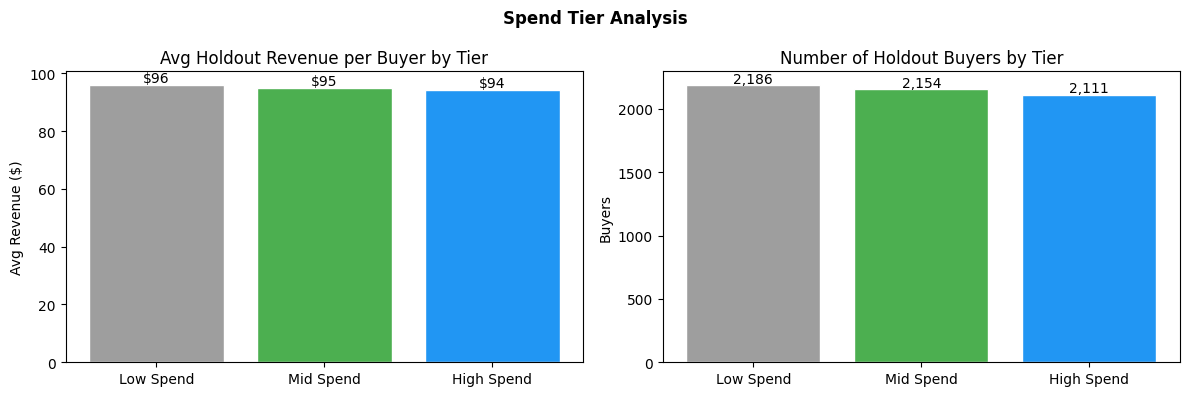

In [5]:
# Visualize revenue by tier
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

colors = ['#9E9E9E', '#4CAF50', '#2196F3']
tiers = ['Low Spend', 'Mid Spend', 'High Spend']

# Average revenue per buyer by tier
avg_revs = [tier_revenue.loc[t, 'avg_holdout_rev'] for t in tiers]
axes[0].bar(tiers, avg_revs, color=colors, edgecolor='white')
axes[0].set_title('Avg Holdout Revenue per Buyer by Tier')
axes[0].set_ylabel('Avg Revenue ($)')
for i, v in enumerate(avg_revs):
    axes[0].text(i, v + 1, f'${v:.0f}', ha='center', fontsize=10)

# Number of buyers per tier
n_buyers = [tier_revenue.loc[t, 'n_buyers'] for t in tiers]
axes[1].bar(tiers, n_buyers, color=colors, edgecolor='white')
axes[1].set_title('Number of Holdout Buyers by Tier')
axes[1].set_ylabel('Buyers')
for i, v in enumerate(n_buyers):
    axes[1].text(i, v + 20, f'{int(v):,}', ha='center', fontsize=10)

plt.suptitle('Spend Tier Analysis', fontweight='bold')
plt.tight_layout()
plt.show()

## 3. Map Expected Revenue to All Customers

In [6]:
# Create tier → expected revenue mapping
tier_avg_map = tier_revenue['avg_holdout_rev'].to_dict()
print("Tier → Expected Revenue mapping:")
for tier, rev in tier_avg_map.items():
    print(f"  {tier}: ${rev:.2f}")

# Map to all customers
df['expected_revenue_if_purchase'] = df['spend_tier'].map(tier_avg_map)

Tier → Expected Revenue mapping:
  Low Spend: $95.88
  Mid Spend: $94.79
  High Spend: $94.08


## 4. Combined CLV

In [7]:
# CLV = P(purchase) x E[revenue | purchase]
df['expected_revenue_if_purchase'] = pd.to_numeric(df['expected_revenue_if_purchase'], errors='coerce')
df['clv_180d'] = df['p_purchase'] * df['expected_revenue_if_purchase']

# Scale to 12-month estimate (approximate linear extrapolation)
df['clv_12m'] = df['clv_180d'] * (365 / 180)

print("=== Combined CLV Distribution ===")
print(f"CLV (180d): ${df['clv_180d'].mean():.2f} avg, ${df['clv_180d'].median():.2f} median")
print(f"CLV (12m):  ${df['clv_12m'].mean():.2f} avg, ${df['clv_12m'].median():.2f} median")
print(f"\nComponents:")
print(f"  P(purchase):     {df['p_purchase'].mean():.4f} avg")
print(f"  E[rev|purchase]: ${df['expected_revenue_if_purchase'].mean():.2f} avg")

print(f"\nCLV (180d) percentiles:")
for p in [10, 25, 50, 75, 90, 95, 99]:
    print(f"  P{p}: ${df['clv_180d'].quantile(p/100):.2f}")

=== Combined CLV Distribution ===
CLV (180d): $11.72 avg, $9.61 median
CLV (12m):  $23.77 avg, $19.50 median

Components:
  P(purchase):     0.1235 avg
  E[rev|purchase]: $94.92 avg

CLV (180d) percentiles:
  P10: $6.40
  P25: $7.57
  P50: $9.61
  P75: $14.42
  P90: $20.92
  P95: $24.37
  P99: $30.87


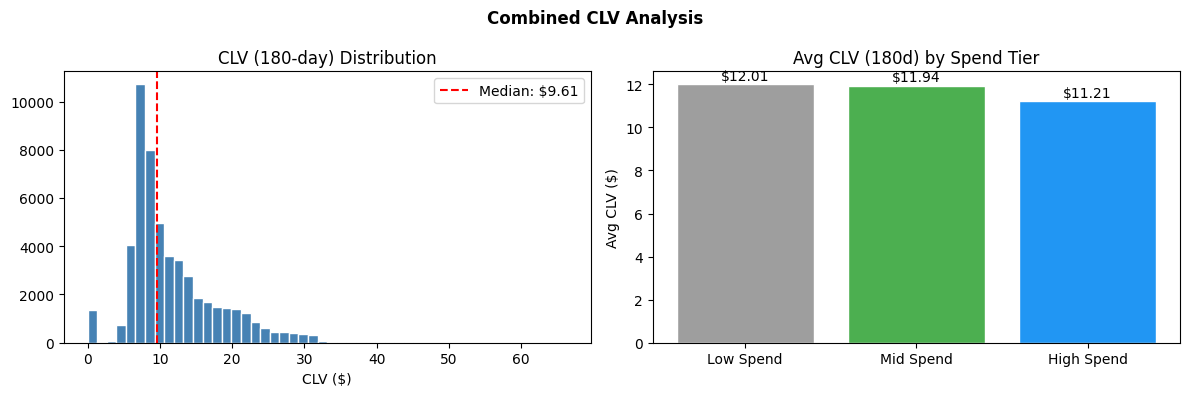

In [8]:
# CLV distribution histogram
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df['clv_180d'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('CLV (180-day) Distribution')
axes[0].set_xlabel('CLV ($)')
axes[0].axvline(df['clv_180d'].median(), color='red', linestyle='--', label=f"Median: ${df['clv_180d'].median():.2f}")
axes[0].legend()

# CLV by spend tier
tier_clv = df.groupby('spend_tier')['clv_180d'].mean()
axes[1].bar(tiers, [tier_clv[t] for t in tiers], color=colors, edgecolor='white')
axes[1].set_title('Avg CLV (180d) by Spend Tier')
axes[1].set_ylabel('Avg CLV ($)')
for i, t in enumerate(tiers):
    axes[1].text(i, tier_clv[t] + 0.2, f'${tier_clv[t]:.2f}', ha='center', fontsize=10)

plt.suptitle('Combined CLV Analysis', fontweight='bold')
plt.tight_layout()
plt.show()

## 5. Sanity Checks

In [9]:
# Check 1: One-time buyers should have lower CLV than repeat buyers
clv_onetime = df.loc[df['frequency'] == 0, 'clv_180d'].mean()
clv_repeat  = df.loc[df['frequency'] >= 1, 'clv_180d'].mean()
print(f"One-time buyer avg CLV (180d): ${clv_onetime:.2f}")
print(f"Repeat buyer avg CLV (180d):   ${clv_repeat:.2f}")
print(f"Check: one-time < repeat: {'PASS' if clv_onetime < clv_repeat else 'FAIL'}")

# Check 2: Top 20% should capture disproportionate share
top20_n = int(len(df) * 0.2)
top20_clv = df.nlargest(top20_n, 'clv_180d')['clv_180d'].sum()
total_clv = df['clv_180d'].sum()
top20_pct = top20_clv / total_clv
print(f"\nTop 20% customers account for {top20_pct:.1%} of total predicted CLV")
print(f"Check: top 20% >= 50%: {'PASS' if top20_pct >= 0.5 else 'WARN (see below)'}")

# Check 3: Total predicted vs actual holdout revenue
total_pred = df['clv_180d'].sum()
total_actual = df['actual_holdout_revenue'].sum()
print(f"\nTotal predicted (180d): ${total_pred:,.0f}")
print(f"Total actual (holdout): ${total_actual:,.0f}")
print(f"Ratio: {total_pred / total_actual:.2f}")

One-time buyer avg CLV (180d): $11.28
Repeat buyer avg CLV (180d):   $12.70
Check: one-time < repeat: PASS

Top 20% customers account for 37.8% of total predicted CLV
Check: top 20% >= 50%: WARN (see below)

Total predicted (180d): $615,373
Total actual (holdout): $612,372
Ratio: 1.00


## 6. Save Outputs

In [10]:
os.makedirs('../data/processed', exist_ok=True)
df.to_csv('../data/processed/clv_scored.csv', index=False)

print(f"Scored data saved to data/processed/clv_scored.csv")
print(f"  Shape: {df.shape[0]:,} x {df.shape[1]}")
print(f"  Key columns: p_purchase, spend_tier, expected_revenue_if_purchase, clv_180d, clv_12m")

Scored data saved to data/processed/clv_scored.csv
  Shape: 52,507 x 40
  Key columns: p_purchase, spend_tier, expected_revenue_if_purchase, clv_180d, clv_12m


In [11]:
print("=" * 55)
print("STAGE 2 SUMMARY: Expected Revenue + Combined CLV")
print("=" * 55)
print(f"Approach:                Spend-tier avg revenue")
print(f"Tiers:                   {', '.join(tiers)}")
print(f"Mean CLV (180d):         ${df['clv_180d'].mean():.2f}")
print(f"Mean CLV (12m):          ${df['clv_12m'].mean():.2f}")
print(f"Total predicted (180d):  ${df['clv_180d'].sum():,.0f}")
print(f"Total actual (holdout):  ${df['actual_holdout_revenue'].sum():,.0f}")
print("=" * 55)
print("\nNext: 04_clv_validation.ipynb")

STAGE 2 SUMMARY: Expected Revenue + Combined CLV
Approach:                Spend-tier avg revenue
Tiers:                   Low Spend, Mid Spend, High Spend
Mean CLV (180d):         $11.72
Mean CLV (12m):          $23.77
Total predicted (180d):  $615,373
Total actual (holdout):  $612,372

Next: 04_clv_validation.ipynb
